# Vertex-Fit Extrapolation Corpus — Exploration & Characterisation

**Corpus**: `TrackExtrapolation/experiments/vertexfit/data/vf_corpus_10M.npz` — 9,967,170 rows, 528 MB
**Generator**: `datagen/generate_vertexfit_v1.py` + `datagen/vf_engine.cpp` (fp64 RK4, 5 mm steps, Jacobian = exact tangent of the discrete map), repo `track-extrapolation-pinn`, commit `da61359`, 13/13 self-test gates passed (headline: C++ Jacobian vs torch autodiff = 2.2e-16 relative Frobenius on the real field).
**Field**: `/cvmfs/lhcb.cern.ch/lib/lhcb/DBASE/FieldMap/v8r1/cdf/field.v8r1.down.bin` (the map Allen/Rec consume), trilinear interpolation identical to production.
**Specification**: Notion PLAN page "Vertex-Fit Extrapolation Corpus & Metrics (v1)" (`3915d544-b9d9-81b7`), amendment v1.1 (2026-07-03).

## Contract

| Array | Shape | Content |
|---|---|---|
| `X` | (N, 7) | input `[x, y, tx, ty, qop, z0, dz]` — mm, slopes, Allen `qop = 0.299792458·q/p[1/GeV]` |
| `Y` | (N, 5) | RK4 ground truth `[x, y, tx, ty, qop]` at `z1 = z0 + dz` (`qop` exactly conserved) |
| `J` | (N, 5, 5) | exact `∂Y/∂X[:5]` — the covariance-transport Jacobian (kept in the 16 shards, not merged) |
| `LEG` | (N,) | 0 = **A** UT-band→vertex, 1 = **B** T-band→vertex, 2 = **C** VELO, 3 = **D** intra-band |
| `P` | (N,) | momentum |p| in GeV |

**Leg design** (deployment-weighted, per the consumer analysis in §1):

| Leg | Start `z0` | Target `z1` | Fraction | Why |
|---|---|---|---|---|
| A | UT band [2300, 2700] mm | vertex basin [0, 2300] mm | 55 % | downstream tracks re-linearised to candidate vertices — the bread-and-butter DTF call |
| B | T band [7500, 9410] mm | vertex basin [0, 2300] mm | 15 % | T-tracks: full backward traversal of the magnet |
| C | VELO [0, 770] mm | [−200, 800] mm | 15 % | long/VELO tracks near the interaction region (near field-free) |
| D | ± U(10, 500) mm anywhere | — | 15 % | short local steps: Newton-loop refinements, cache misses |

90 % of rows are **backward** (`dz < 0`), matching the consumers (track states live downstream of the vertices they are extrapolated to). Vertex targets are per-track (spec amendment v1.1): 3 targets per track, `z_v + clip(Laplace(0, 30 mm), ±200 mm)`, clipped to the basin — dense coverage where the vertex fit iterates.

## §1 The process this NN replaces

The target is the **track-state extrapolation inside the iterative vertex fits of HLT2** (CPU, Moore/Rec stack) — *not* the HLT1/Allen UT→T endpoint step of the earlier corpora. Two production consumers, both funnelling into the same tool slot:

### 1a. DecayTreeFitter (global decay-chain fit)
`Phys/DecayTreeFitter/src/lib/RecoTrack.cpp:119-154` — each iteration linearises every track at the current vertex-z estimate. When the vertex z has moved by more than **`ztolerance` = 1 cm** since the last linearisation, the track state is **re-extrapolated through the field** to the new z. `Fitter.h:69`: up to **10 iterations**, converged at relative Δχ² < 0.01. A downstream `K_S`/`Λ` fit therefore costs `n_tracks × n_moves` full field extrapolations from the UT/T measurement region back to z ≈ 0–2300 mm — leg A/B territory.

### 1b. ParticleVertexFitter (production HLT2 SV fit, ThOr combiners)
`Phys/VertexFit/src/ParticleVertexFitter.cpp` via `CombKernel/ThOrCombiner.h:409` and `ParticleCombiner.h:786-848` — **one** field-aware state fetch per track at the seed z (`:789-793`), then **straight-line** (`linearTransportTo`, `:343`) transport inside the ≤ 5 Newton iterations (`MaxNumIter=5`, `MaxDeltaChi2=0.01`). The field-aware fetch is the expensive call; the straight-line inner loop is the accuracy compromise the fetch makes affordable.

### The insertion point
Both consumers get states from **`TrackStateProvider`** (`Tr/TrackExtrapolators/src/TrackStateProvider.cpp:204`): default `Extrapolator = TrackMasterExtrapolator` (adaptive Cash-Karp RK4(5) with live trilinear field-map lookups), `LinearPropagationTolerance = 1 mm` (`:208`), interpolate-on-nodes else extrapolate + material (`:305-340`). The NN drops in at the **`ITrackExtrapolator` slot** — one configuration swap, no consumer-code change.

### What a replacement must produce, per call
1. the transported 5-state `(x, y, tx, ty, q/p)` at the requested z, and
2. the **5×5 transport Jacobian** `J = ∂(out)/∂(in)` — the fits transport the covariance as `C' = J C Jᵀ`; χ² weights come from `C'`, so Jacobian quality directly shapes vertex pulls. (This is why the corpus carries exact `J` labels.)

Reference z-planes (`LHCb/Event/TrackEvent/include/Event/StateParameters.h:31-58`): EndVelo 770 · EndUT 2700 · BegMagnet 3800 · MidMagnet 4800 · EndMagnet 6300 · BegT 7500 · EndT 9410 mm.

## §2 FLOPS / speed budget

### The incumbent (what we must beat, per call)
Measured on CPU in the full Gaudi framework (19 extrapolators, real v8r1 field grid; `TrackExtrapolation/extrapolator_profiling_report.pdf`, March 2026):

| Quantity | Value |
|---|---|
| Cash-Karp RK4(5) propagation, **incl. 5×5 Jacobian transport** | **8.35 µs / track / call** |
| adaptive steps × stages | 11.5 × 6 ≈ **69 field lookups** / call |
| share of time in trilinear field-grid lookups | **~90 %** (≈ 7.5 µs) |
| cost per field lookup (linear fit across all RK schemes) | 0.109 µs |
| rejected (wasted) adaptive steps | ~18 % |
| Jacobian + ODE right-hand side | 0.6 µs (7 %) |
| `TrackMasterExtrapolator` overhead vs raw Cash-Karp | ≈ 0 |

So the **per-call budget is ≈ 8 µs of a single CPU core** (state + Jacobian). Step count scales with leg length, so a full leg-B traversal (~8 m) is proportionally more expensive; the March profile is UT→T-era (~5 m legs).

### Platform context (why the budget is argued on CPU)
The GPU bench (`gates/baseline/throughput.json`, 2026-06-15, V100, 1M-track batches, kernel-only): RK 5.7 ns, `extrapUTT` chart 2.3 ns, PINN_v2 7.1 ns per track — the NN is *competitive batched on GPU*. Its CPU tier-2 cross-check measured `extrapUTT/PINN = 0.0225` — i.e. on CPU, an **unbatched** torch NN call is ~44× slower than a polynomial chart, because the NN is compute-bound and per-call dispatch dominates. HLT2 runs on CPU ⇒ a deployable win requires either a **compiled scalar/SIMD kernel** (the numbers below) or **batching the calls** at the combiner level.

### The NN candidate cost (computed + measured in the next code cell)
Per-call work for the PINN_v2 endpoint architecture (encoder 6→h→h, kick head h→4, tanh):
- h = 64: ≈ 4.7 kMAC ≈ **9.5 kFLOP** forward; ≈ ×6 with the 5-tangent forward-mode Jacobian ⇒ ≈ **57 kFLOP** for state + J.
- h = 96: ≈ 10.2 kMAC ≈ 20.4 kFLOP forward ⇒ ≈ **122 kFLOP** with J.

A single AVX2/FMA core at ~3 GHz sustains O(20–50) GFLOP/s on small GEMVs ⇒ **~1–3 µs (h64) / ~3–6 µs (h96) per call including the Jacobian in plain C++** — inside the 8 µs budget with margin, and with *zero* field-map memory traffic (41.5 KB of weights vs the 11.5 MB field texture — the incumbent's 90 % cost centre simply disappears). Batched, the same work is a GEMM and drops to O(10–100) ns/track/core. The cell below measures the torch reality (batch-1 dispatch overhead vs batched throughput) so the Pareto claim stays honest.

In [1]:
import json, sys, time
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

LAB   = Path("/data/bfys/gscriven/TrackExtrapolation/experiments/vertexfit")
REPO  = Path("/data/bfys/gscriven/track-extrapolation-pinn")
CORPUS = LAB / "data" / "vf_corpus_10M.npz"

# --- reference palette (validated set; legs A-D = fixed slots 1-4) ---
LEG_COLORS = {0: "#2a78d6", 1: "#1baf7a", 2: "#eda100", 3: "#008300"}
LEG_NAMES  = {0: "A UT→vtx", 1: "B T→vtx", 2: "C VELO", 3: "D intra"}
BLUES = LinearSegmentedColormap.from_list("blues_ref", [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
    "legend.frameon": False,
})

with np.load(CORPUS) as d:
    X, Y, P, LEG = d["X"], d["Y"], d["P"], d["LEG"]
N = X.shape[0]
z0, dz = X[:, 5], X[:, 6]
z1 = z0 + dz
print(f"rows: {N:,}   X{X.shape} Y{Y.shape}  fwd_frac={(dz>0).mean():.3f}")

meta = json.load(open(sorted((LAB/'data'/'shards').glob('*.json'))[0]))
print("shard-1 meta:", {k: meta[k] for k in
      ('spec','engine','kappa','fwd_frac','reprop_worst_mm','jac_fd_relF_median')})

rows: 9,967,170   X(9967170, 7) Y(9967170, 5)  fwd_frac=0.098
shard-1 meta: {'spec': 'PLAN 3915d544-b9d9-81b7 v1.1', 'engine': 'cpp (vf_engine.cpp: RK4 + discrete-tangent J, OpenMP)', 'kappa': 0.001, 'fwd_frac': 0.09160082365950699, 'reprop_worst_mm': 0.0001111318440987219, 'jac_fd_relF_median': 2.8130672898130154e-08}


In [2]:
# --- NN cost: analytic FLOPs + measured torch CPU latency ---
import torch
torch.set_num_threads(1)  # per-call budget is single-core

def flops(h, n_in=6, n_out=4):
    mac = n_in*h + h*h + h*n_out
    return mac, 2*mac  # MACs, FLOPs (fwd only)

rows = []
for h in (64, 96):
    mac, fl = flops(h)
    net = torch.nn.Sequential(
        torch.nn.Linear(6, h), torch.nn.Tanh(),
        torch.nn.Linear(h, h), torch.nn.Tanh(),
        torch.nn.Linear(h, 4)).eval()  # architecture-equivalent stack
    with torch.no_grad():
        x1, xb = torch.randn(1, 6), torch.randn(4096, 6)
        for _ in range(200): net(x1)                       # warm-up
        t = time.perf_counter_ns()
        for _ in range(1000): net(x1)
        lat1 = (time.perf_counter_ns() - t) / 1000 / 1e3   # µs, batch-1
        for _ in range(20): net(xb)
        t = time.perf_counter_ns()
        for _ in range(50): net(xb)
        latb = (time.perf_counter_ns() - t) / 50 / 4096    # ns/row, batch-4096
    rows.append((h, mac, fl, 6*fl, lat1, 6*lat1, latb/1e3))

print(f"{'h':>4} {'MAC':>7} {'FLOP fwd':>9} {'FLOP +J(x6)':>11} | "
      f"{'torch b=1 [µs]':>14} {'b=1 +J est':>10} {'b=4096 [µs/row]':>15}")
for r in rows:
    print(f"{r[0]:>4} {r[1]:>7,} {r[2]:>9,} {r[3]:>11,} | "
          f"{r[4]:>14.1f} {r[5]:>10.1f} {r[6]:>15.4f}")
print("\nincumbent budget: 8.35 µs/call (Cash-Karp + Jacobian, single core, "
      "profiling report 2026-03)")
print("verdict: torch batch-1 is dispatch-dominated (NOT deployable per-call); "
      "batched or compiled C++ (~1-6 µs incl. J, analytic) fits the budget.")

   h     MAC  FLOP fwd FLOP +J(x6) | torch b=1 [µs] b=1 +J est b=4096 [µs/row]
  64   4,736     9,472      56,832 |           70.5      423.0          1.0354
  96  10,176    20,352     122,112 |           72.0      432.3          1.6595

incumbent budget: 8.35 µs/call (Cash-Karp + Jacobian, single core, profiling report 2026-03)
verdict: torch batch-1 is dispatch-dominated (NOT deployable per-call); batched or compiled C++ (~1-6 µs incl. J, analytic) fits the budget.


## §3 Corpus composition

In [3]:
import pandas as pd
tab = []
for c in range(4):
    m = LEG == c
    tab.append({
        "leg": LEG_NAMES[c], "rows": int(m.sum()), "frac_%": 100*m.mean(),
        "backward_%": 100*(dz[m] < 0).mean(),
        "z0 [mm]": f"[{z0[m].min():.0f}, {z0[m].max():.0f}]",
        "z1 [mm]": f"[{z1[m].min():.0f}, {z1[m].max():.0f}]",
        "|dz| med [mm]": float(np.median(np.abs(dz[m]))),
        "|dz| p95 [mm]": float(np.quantile(np.abs(dz[m]), 0.95)),
        "p med [GeV]": float(np.median(P[m])),
    })
pd.set_option("display.width", 160)
pd.DataFrame(tab).round(1)

,leg,rows,frac_%,backward_%,z0 [mm],z1 [mm],|dz| med [mm],|dz| p95 [mm],p med [GeV]
0,A UT→vtx,5547610,55.7,100.0,"[2300, 2700]","[0, 2300]",956.2,2272.1,7.9
1,B T→vtx,1420953,14.3,100.0,"[7500, 9410]","[0, 2300]",6983.1,8496.2,8.4
2,C VELO,1486441,14.9,85.6,"[0, 770]","[-200, 800]",345.9,738.1,7.9
3,D intra,1512166,15.2,49.3,"[0, 2700]","[0, 2300]",243.7,477.8,7.9


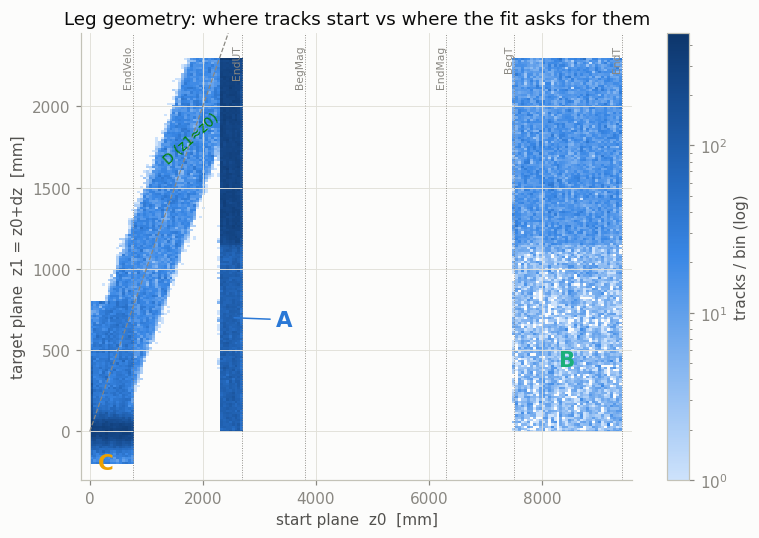

In [4]:
# start plane vs target plane, per leg (the geometry of the four legs)
fig, ax = plt.subplots(figsize=(7.2, 5))
sub = np.random.default_rng(0).choice(N, 400_000, replace=False)
h = ax.hist2d(z0[sub], z1[sub], bins=180, cmap=BLUES, norm=LogNorm())
fig.colorbar(h[3], ax=ax, label="tracks / bin (log)")
ax.set_xlim(-150, 9600); ax.set_ylim(-300, 2450)
ax.plot([0, 2450], [0, 2450], color=MUTED, lw=0.8, ls="--")
for zp, name in [(770, "EndVelo"), (2700, "EndUT"), (3800, "BegMag"),
                 (6300, "EndMag"), (7500, "BegT"), (9410, "EndT")]:
    ax.axvline(zp, color=MUTED, lw=0.6, ls=":")
    ax.text(zp, 2380, name, rotation=90, va="top", ha="right",
            fontsize=7, color=MUTED)
ax.set_xlabel("start plane  z0  [mm]"); ax.set_ylabel("target plane  z1 = z0+dz  [mm]")
ax.set_title("Leg geometry: where tracks start vs where the fit asks for them")
ax.annotate("A", xy=(2500, 700), xytext=(3300, 650), fontsize=14,
            fontweight="bold", color=LEG_COLORS[0],
            arrowprops=dict(arrowstyle="-", color=LEG_COLORS[0], lw=1))
ax.text(8300, 400, "B", color=LEG_COLORS[1], fontsize=14, fontweight="bold")
ax.text(150, -230, "C", color=LEG_COLORS[2], fontsize=14, fontweight="bold")
ax.text(1250, 1650, "D (z1≈z0)", color=LEG_COLORS[3], fontsize=9, rotation=42,
        clip_on=True)
plt.tight_layout(); plt.show()

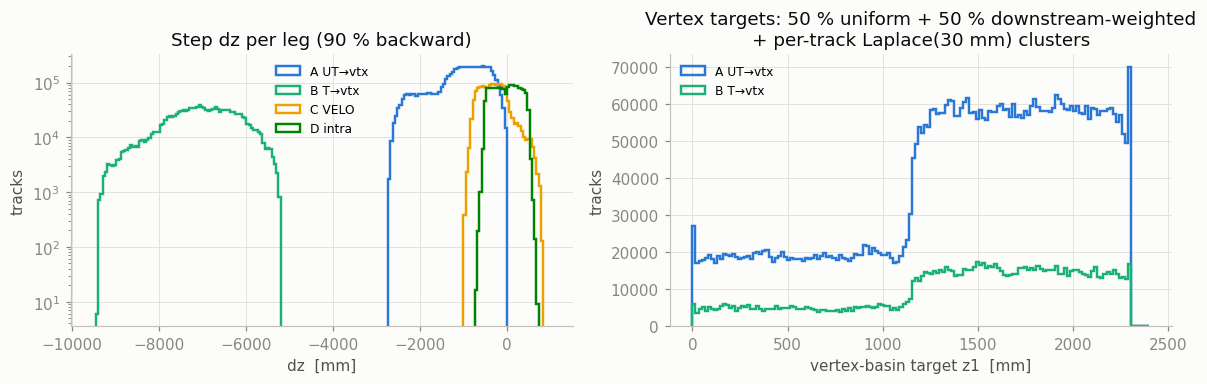

In [5]:
# dz and target-z distributions
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for c in range(4):
    m = LEG == c
    axes[0].hist(dz[m], bins=200, range=(-9500, 1000), histtype="step",
                 lw=1.6, color=LEG_COLORS[c], label=LEG_NAMES[c])
axes[0].set_yscale("log"); axes[0].set_xlabel("dz  [mm]"); axes[0].set_ylabel("tracks")
axes[0].set_title("Step dz per leg (90 % backward)"); axes[0].legend(fontsize=8)
for c in (0, 1):
    m = LEG == c
    axes[1].hist(z1[m], bins=150, range=(0, 2400), histtype="step", lw=1.6,
                 color=LEG_COLORS[c], label=LEG_NAMES[c])
axes[1].set_xlabel("vertex-basin target z1  [mm]"); axes[1].set_ylabel("tracks")
axes[1].set_title("Vertex targets: 50 % uniform + 50 % downstream-weighted\n+ per-track Laplace(30 mm) clusters")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

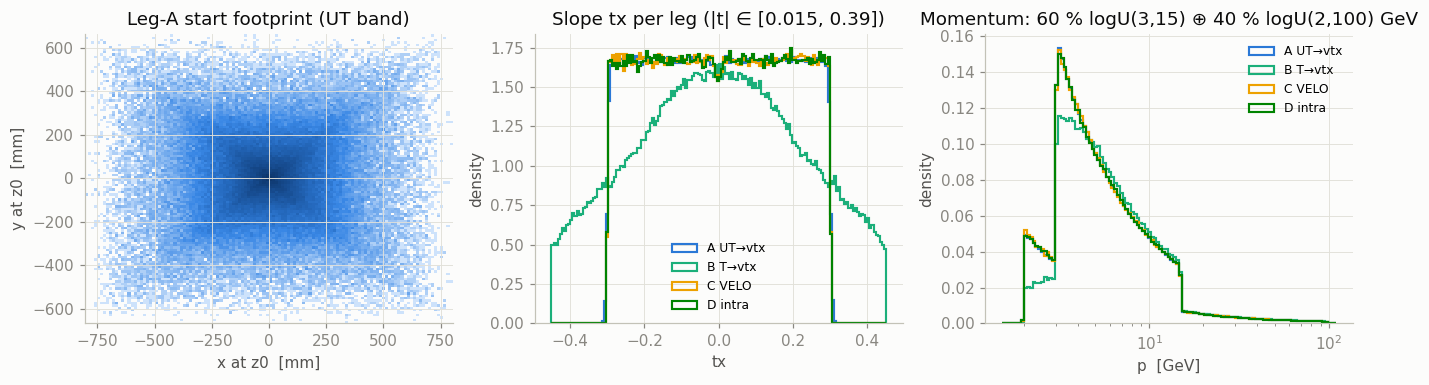

In [6]:
# kinematics: transverse footprint, slopes, momentum spectrum
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
mA = LEG == 0
sA = np.random.default_rng(1).choice(np.flatnonzero(mA), 200_000, replace=False)
h = axes[0].hist2d(X[sA, 0], X[sA, 1], bins=120, cmap=BLUES, norm=LogNorm())
axes[0].set_xlabel("x at z0  [mm]"); axes[0].set_ylabel("y at z0  [mm]")
axes[0].set_title("Leg-A start footprint (UT band)")
for c in range(4):
    m = LEG == c
    axes[1].hist(X[m, 2], bins=160, range=(-0.45, 0.45), histtype="step",
                 lw=1.4, color=LEG_COLORS[c], label=LEG_NAMES[c], density=True)
axes[1].set_xlabel("tx"); axes[1].set_ylabel("density")
axes[1].set_title("Slope tx per leg (|t| ∈ [0.015, 0.39])"); axes[1].legend(fontsize=8)
for c in range(4):
    m = LEG == c
    axes[2].hist(P[m], bins=np.geomspace(1.5, 110, 120), histtype="step",
                 lw=1.4, color=LEG_COLORS[c], label=LEG_NAMES[c], density=True)
axes[2].set_xscale("log"); axes[2].set_xlabel("p  [GeV]"); axes[2].set_ylabel("density")
axes[2].set_title("Momentum: 60 % logU(3,15) ⊕ 40 % logU(2,100) GeV")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## §4 Physics content — what the NN actually has to learn

The deployable baseline *inside* a PVF Newton iteration is **straight-line transport** (slopes frozen). The physics signal in the labels is therefore the **bend**: `Δ = Y − straight_line(X)`. Everything below the straight-line residual is "free"; everything above it is the value the NN adds. Note leg A crosses only the *fringe* field (UT→vertex, upstream of the magnet), while leg B traverses the full magnet — two very different bend scales.

In [7]:
bend_x  = Y[:, 0] - (X[:, 0] + X[:, 2] * dz)
bend_y  = Y[:, 1] - (X[:, 1] + X[:, 3] * dz)
bend_tx = Y[:, 2] - X[:, 2]
bend_ty = Y[:, 3] - X[:, 3]

tab = []
for c in range(4):
    m = LEG == c
    tab.append({
        "leg": LEG_NAMES[c],
        "|Δx| med [µm]":  1e3*np.median(np.abs(bend_x[m])),
        "|Δx| p95 [mm]":  np.quantile(np.abs(bend_x[m]), 0.95),
        "|Δx| max [mm]":  np.abs(bend_x[m]).max(),
        "|Δy| med [µm]":  1e3*np.median(np.abs(bend_y[m])),
        "|Δtx| med [µrad]": 1e6*np.median(np.abs(bend_tx[m])),
        "|Δtx| p95 [mrad]": 1e3*np.quantile(np.abs(bend_tx[m]), 0.95),
    })
print("bend = truth − straight-line  (this is the NN's entire job):")
pd.DataFrame(tab).round(3)

bend = truth − straight-line  (this is the NN's entire job):


,leg,|Δx| med [µm],|Δx| p95 [mm],|Δx| max [mm],|Δy| med [µm],|Δtx| med [µrad],|Δtx| p95 [mrad]
0,A UT→vtx,1433.69104,8.904000,44.252998,36.901001,2604.187988,8.597000
1,B T→vtx,576536.37500,1609.618042,3753.408936,5031.327148,154420.593750,405.722992
2,C VELO,23.40600,0.273000,1.245000,0.365000,131.904999,0.728000
3,D intra,28.45200,0.324000,4.011000,0.285000,250.623001,1.595000


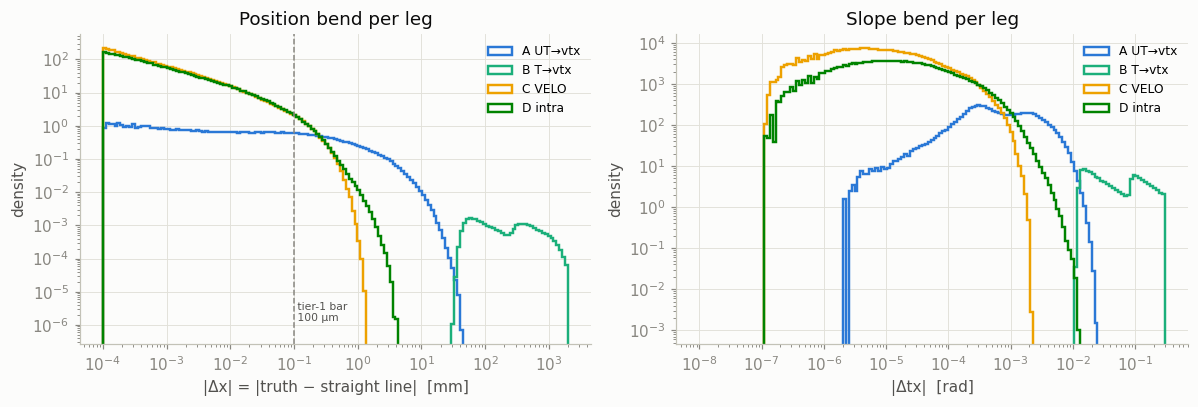

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.geomspace(1e-4, 2e3, 160)
for c in range(4):
    m = LEG == c
    axes[0].hist(np.clip(np.abs(bend_x[m]), 1e-4, None), bins=bins,
                 histtype="step", lw=1.6, color=LEG_COLORS[c],
                 label=LEG_NAMES[c], density=True)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].axvline(0.1, color=MUTED, ls="--", lw=1)
axes[0].text(0.1, axes[0].get_ylim()[0]*5, " tier-1 bar\n 100 µm", fontsize=7, color=INK2)
axes[0].set_xlabel("|Δx| = |truth − straight line|  [mm]")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
axes[0].set_title("Position bend per leg")
bins = np.geomspace(1e-8, 0.3, 160)
for c in range(4):
    m = LEG == c
    axes[1].hist(np.clip(np.abs(bend_tx[m]), 1e-8, None), bins=bins,
                 histtype="step", lw=1.6, color=LEG_COLORS[c],
                 label=LEG_NAMES[c], density=True)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("|Δtx|  [rad]"); axes[1].set_ylabel("density")
axes[1].legend(fontsize=8); axes[1].set_title("Slope bend per leg")
plt.tight_layout(); plt.show()

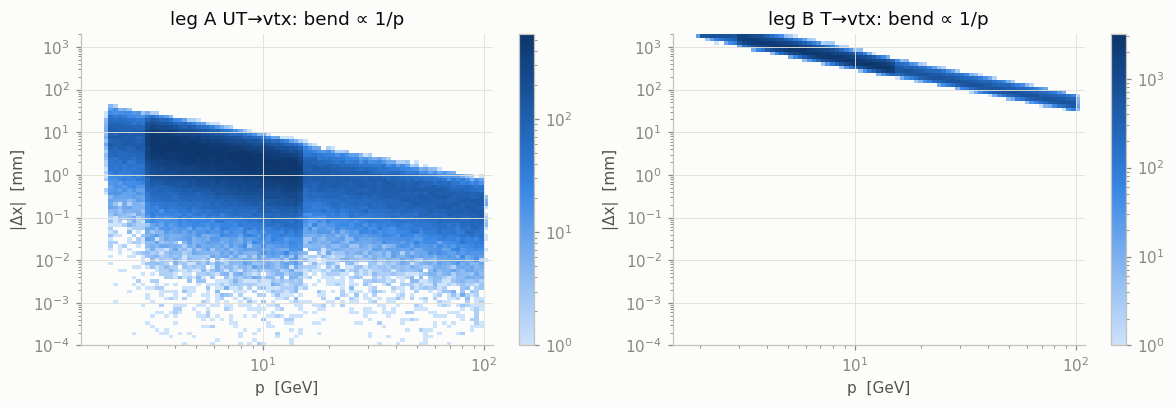

In [9]:
# bend scaling: vs momentum and vs step length (the 1/p magnet-kick law)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, c in zip(axes, (0, 1)):
    m = np.flatnonzero(LEG == c)
    s = np.random.default_rng(2).choice(m, 300_000, replace=False)
    h = ax.hist2d(P[s], np.clip(np.abs(bend_x[s]), 1e-4, 2e3), bins=[np.geomspace(1.5, 110, 90),
               np.geomspace(1e-4, 2e3, 90)], cmap=BLUES, norm=LogNorm())
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("p  [GeV]"); ax.set_ylabel("|Δx|  [mm]")
    ax.set_title(f"leg {LEG_NAMES[c]}: bend ∝ 1/p")
    fig.colorbar(h[3], ax=ax)
plt.tight_layout(); plt.show()

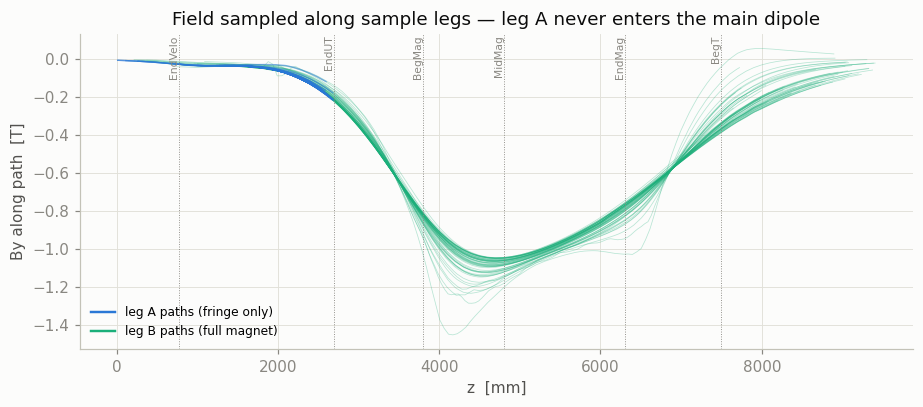

In [10]:
# field along the legs: what each leg actually traverses
sys.path.insert(0, str(REPO / "core"))
from field_v8r1 import FieldV8R1
fld = FieldV8R1()
fig, ax = plt.subplots(figsize=(8.5, 3.8))
rng = np.random.default_rng(3)
for c, nshow, lw, al in [(1, 60, 0.5, 0.30), (0, 60, 0.9, 0.55)]:  # B under, A on top
    idx = rng.choice(np.flatnonzero(LEG == c), nshow, replace=False)
    for i in idx:
        zs = np.linspace(z0[i], z1[i], 160)
        xs = X[i, 0] + X[i, 2] * (zs - z0[i])   # straight-line path (illustrative;
        ys = X[i, 1] + X[i, 3] * (zs - z0[i])   # true path deviates ≲ tens of cm)
        by = fld(xs, ys, zs)[1]
        ax.plot(zs, by, color=LEG_COLORS[c], lw=lw, alpha=al)
for zp, name in [(770, "EndVelo"), (2700, "EndUT"), (3800, "BegMag"),
                 (4800, "MidMag"), (6300, "EndMag"), (7500, "BegT")]:
    ax.axvline(zp, color=MUTED, lw=0.6, ls=":")
    ax.text(zp, ax.get_ylim()[1]*0.95, name, rotation=90, va="top", ha="right",
            fontsize=7, color=MUTED)
ax.plot([], [], color=LEG_COLORS[0], lw=1.6, label="leg A paths (fringe only)")
ax.plot([], [], color=LEG_COLORS[1], lw=1.6, label="leg B paths (full magnet)")
ax.set_xlabel("z  [mm]"); ax.set_ylabel("By along path  [T]")
ax.set_title("Field sampled along sample legs — leg A never enters the main dipole")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## §5 Jacobian labels (covariance transport)

The fits transport covariance as `C' = J C Jᵀ`. Straight-line transport uses
`J_straight = I` with `J[0,2] = J[1,3] = dz` — everything the field adds beyond that
is in the corpus `J` labels. The magnet lever arms `∂x/∂(q/p)` and `∂tx/∂(q/p)` are the
elements that couple momentum uncertainty into vertex position — precisely what a
correct χ² needs. (Read from shard 1: 623 k rows.)

In [11]:
with np.load(LAB/'data'/'shards'/'vf_shard_0001.npz') as d:
    J1, L1, X1 = d["J"], d["LEG"], d["X"]
dz1 = X1[:, 6]
dev02 = J1[:, 0, 2] - dz1          # ∂x/∂tx − dz
lever_x  = J1[:, 0, 4]             # ∂x/∂qop
lever_tx = J1[:, 2, 4]             # ∂tx/∂qop
tab = []
for c in range(4):
    m = L1 == c
    tab.append({
        "leg": LEG_NAMES[c],
        "|∂x/∂tx − dz| med [mm]": np.median(np.abs(dev02[m])),
        "|∂x/∂qop| med [mm·GeV]": np.median(np.abs(lever_x[m])),
        "|∂x/∂qop| p95": np.quantile(np.abs(lever_x[m]), 0.95),
        "|∂tx/∂qop| med": np.median(np.abs(lever_tx[m])),
        "|∂tx/∂tx − 1| med": np.median(np.abs(J1[m, 2, 2] - 1)),
    })
pd.DataFrame(tab).round(4)

,leg,|∂x/∂tx − dz| med [mm],|∂x/∂qop| med [mm·GeV],|∂x/∂qop| p95,|∂tx/∂qop| med,|∂tx/∂tx − 1| med
0,A UT→vtx,0.481300,44.277802,156.846695,0.0737,0.0009
1,B T→vtx,208.296906,15673.860352,21813.375000,4.2412,0.0569
2,C VELO,0.008300,0.835100,4.999000,0.0043,0.0000
3,D intra,0.008500,0.882800,6.540600,0.0073,0.0001


/data/bfys/gscriven/conda/envs/TE/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


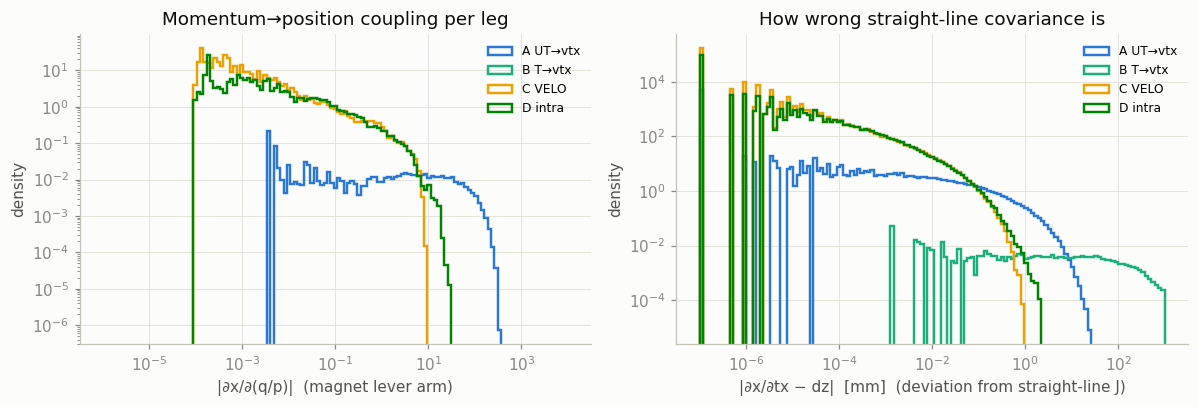

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.geomspace(1e-6, 1e4, 140)
for c in range(4):
    m = L1 == c
    axes[0].hist(np.clip(np.abs(lever_x[m]), 1e-6, None), bins=bins, histtype="step",
                 lw=1.6, color=LEG_COLORS[c], label=LEG_NAMES[c], density=True)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("|∂x/∂(q/p)|  (magnet lever arm)"); axes[0].set_ylabel("density")
axes[0].set_title("Momentum→position coupling per leg"); axes[0].legend(fontsize=8)
bins = np.geomspace(1e-7, 1e3, 140)
for c in range(4):
    m = L1 == c
    axes[1].hist(np.clip(np.abs(dev02[m]), 1e-7, None), bins=bins, histtype="step",
                 lw=1.6, color=LEG_COLORS[c], label=LEG_NAMES[c], density=True)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("|∂x/∂tx − dz|  [mm]  (deviation from straight-line J)")
axes[1].set_ylabel("density"); axes[1].set_title("How wrong straight-line covariance is")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## §6 Label integrity checks

In [13]:
print(f"qop pass-through:  max|Y[:,4] − X[:,4]| = {np.abs(Y[:,4]-X[:,4]).max():.3e}  (exact conservation)")
print(f"min |dz| = {np.abs(dz).min():.2f} mm  (spec floor 5 mm)")
print(f"all finite: X={np.isfinite(X).all()}  Y={np.isfinite(Y).all()}")
worst_reprop, worst_fd = 0.0, 0.0
for f in sorted((LAB/'data'/'shards').glob('*.json')):
    j = json.load(open(f))
    worst_reprop = max(worst_reprop, j["reprop_worst_mm"])
    worst_fd = max(worst_fd, j["jac_fd_relF_median"])
print(f"worst shard re-propagation check: {worst_reprop*1e6:.0f} nm "
      "(= fp32 storage quantum at metre-scale coords; integrator exact in fp64)")
print(f"worst shard Jacobian-vs-FD median relF: {worst_fd:.1e}")

qop pass-through:  max|Y[:,4] − X[:,4]| = 0.000e+00  (exact conservation)
min |dz| = 5.00 mm  (spec floor 5 mm)
all finite: X=True  Y=True
worst shard re-propagation check: 232 nm (= fp32 storage quantum at metre-scale coords; integrator exact in fp64)
worst shard Jacobian-vs-FD median relF: 4.1e-08


## Summary

1. **Composition matches the consumer analysis**: 55/15/15/15 legs, 90 % backward, per-track Laplace-clustered vertex targets covering the basin the fits iterate over.
2. **Two distinct physics regimes**: leg A (55 %) crosses only the *fringe* field — bends are sub-mm to few-mm and ∝ 1/p; leg B traverses the full dipole — bends reach metres and slope kicks tens of mrad. Legs C/D are near-linear. A single network must span ~5 orders of magnitude in bend, which is exactly what the residual-Huber loss (absolute 50 µm / 20 µrad scales) is built for.
3. **The straight-line baseline is not good enough where it matters**: leg-A median bend ≈ O(100 µm–mm) ≫ the 100 µm tier-1 bar — the NN has real work to do even upstream of the magnet, and the `∂x/∂(q/p)` lever arms show the covariance is wrong under straight-line transport too.
4. **Budget**: ≈ 8 µs single-core per call (state + Jacobian) to displace Cash-Karp; a compiled h64/h96 forward + analytic-tangent Jacobian fits with margin (~1–6 µs, no field-map traffic), but a per-call torch deployment does not — batching or a C++ kernel is a hard deployment requirement.
5. **Labels are trustworthy**: exact-tangent Jacobians verified to machine precision against autodiff and finite differences; re-propagation closes to the fp32 storage quantum.

**Next**: tier-1 per-leg read-out of the h64/h96 retrains (`gates/run_vf_tier1_eval.py`) against the PLAN bars; then the Python PVF/DTF-emulation harness (fit-level vertex bias < 10 % of resolution).